# Examen MF1


Utiliza el dataset de vehículos para ayudar a nuestra empresa a automatizar el sistema de tasación de coches. Lee detenidamente la descripción de los datos.

El objetivo es que, al recibir un nuevo vehículo, podamos **predecir el precio** de venta óptimo. Tu jefa te dice que en unas pocas horas quiere un primer prototipo.

Este examen consta de 5 apartados, cada uno con subapartados específicos y puntuación asignada. La puntuación global por apartado es:

1. **Entendimiento de los datos**: 1.5 puntos.
2. **Preparación de los datos**: 3.25 puntos.
3. **Modelado**: 3.25 puntos.
4. **Evaluación final**: 1 punto.
5. **Conclusiones**: 1 punto.

Además, se otorgará hasta **1 punto extra** por aportes extraordinarios adicionales. La nota final se calculará como el mínimo(10, nota obtenida).

Consideraciones:
- Para evaluar los modelos, nuestra empresa ha decidido que el **Balanced accuracy** es la mejor opción en este caso.
- Las preguntas que requieran una justificación escrita estarán indicadas en **negrita** y con frases como "justifica tu decisión" o "comenta".
- En las respuestas no hace falta escribir mucho texto, solo una justificación lógica y razonable.
- Si se pide una justificación o un comentario y no se proporciona, la pregunta puede recibir 0 puntos, independientemente de que el código sea correcto.
- Si el código y la justificación no son coherentes entre sí, la calificación se verá penalizada.
- Si no se pide una explicación, no es necesario proporcionar una.
- Cometer errores de metodología graves (como "data leakage" o un uso inadecuado del conjunto de test) puede suponer una calificación de 0 en los apartados correspondientes.

El 15 de abril de 1912, durante su viaje inaugural, 
el ampliamente considerado "insumergible" RMS Titanic se hundió 
tras chocar con un iceberg. 
Lamentablemente, no había suficientes botes salvavidas para todos a bordo, 
lo que resultó en la muerte de 1502 de los 2224 pasajeros y tripulación.

Aunque hubo un cierto elemento de suerte en sobrevivir, 
parece que algunos grupos de personas tenían más probabilidades 
de sobrevivir que otros.


Survived: Variable objetivo (0 = no sobrevivió, 1 = sobrevivió).

Pclass: Clase del billete (1ª, 2ª, 3ª).

Name: Nombre completo.

Sex: Género del pasajero.

Age: Edad del pasajero (años).

SibSp: Número de hermanos/esposos a bordo.

Parch: Número de padres/hijos a bordo.

Fare: Precio pagado por el billete.

Embarked: Puerto de embarque (C = Cherburgo, Q = Queenstown, S = Southampton).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y Pipelines de scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,StandardScaler
from sklearn.impute import SimpleImputer

# Modelos de Clasificación
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Metrics
from sklearn.metrics import balanced_accuracy_score, accuracy_score, precision_score, recall_score, make_scorer

# Métricas de Clasificación
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor


# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import balanced_accuracy_score, accuracy_score, precision_score, recall_score, make_scorer

# Validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Integración de TabPFN v3 para Clasificación (Ignorando límites de CPU)
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False

import warnings
warnings.filterwarnings('ignore')

# 1. Entendimiento de los datos (Data Understanding)

## 1.1. Descripción de los datos

### 1.1.1. Carga el dataset de vehículos (0.05 puntos)

In [2]:
# Carga de los datos de depósitos bancarios
df = pd.read_csv('data/titanic.csv')

print(f"Dimensiones iniciales del dataset: {df.shape}")

Dimensiones iniciales del dataset: (891, 9)


In [3]:
df

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,23.4500,S
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C


### 1.1.2. Inspección básica (0.45 puntos)

Haz una inspección básica como consideres más oportuno. Por ejemplo ver el tamaño del dataset, primeras filas, tipos de columnas, etc.

**Alguna observación interesante?**

In [4]:
print(f"Dimensiones del dataset original: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
print("Primeras 3 filas de la tabla:")
display(df.head(3))

Dimensiones del dataset original: 891 filas y 9 columnas.

Primeras 3 filas de la tabla:


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S


## 1.2. Exploración de los datos (EDA)

Realiza una visualización básica de los datos.

### 1.2.1. Distribuciones (0.5 puntos)

**Comenta** si observas alguna cosa relevante. En caso de que no haya nada raro o especial, una respuesta del tipo *"No se aprecia nada relevante, ya que (...)."* es perfectamente válida.

In [5]:
# Análisis preliminar de calidad de datos
print("\n=== ANÁLISIS PRELIMINAR DE CALIDAD ===")

# Detección rápida de valores nulos
null_counts = df.isnull().sum()
print("\nValores nulos por columna:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No se detectaron valores nulos directamente.")

# Detección rápida de filas duplicadas
duplicated_rows = df.duplicated().sum()
print(f"\nFilas completamente duplicadas detectadas: {duplicated_rows}")

# Cantidad de pernas a bodo por sexo -> 577 hombres y 314 mujeres
print('Personas a bordo por sexo')
df['Sex'].value_counts()


=== ANÁLISIS PRELIMINAR DE CALIDAD ===

Valores nulos por columna:
Age         174
Embarked      2
dtype: int64

Filas completamente duplicadas detectadas: 0
Personas a bordo por sexo


Sex
male      577
female    314
Name: count, dtype: int64

In [6]:
df['Survived'].value_counts()

Survived
 0    549
 1    339
-1      3
Name: count, dtype: int64

### 1.2.2. Correlación (0.5 puntos)

**Comenta** si observas alguna cosa relevante. En caso de que no haya nada raro o especial, una respuesta del tipo *"No se aprecia nada relevante, ya que (...)."* es perfectamente válida.

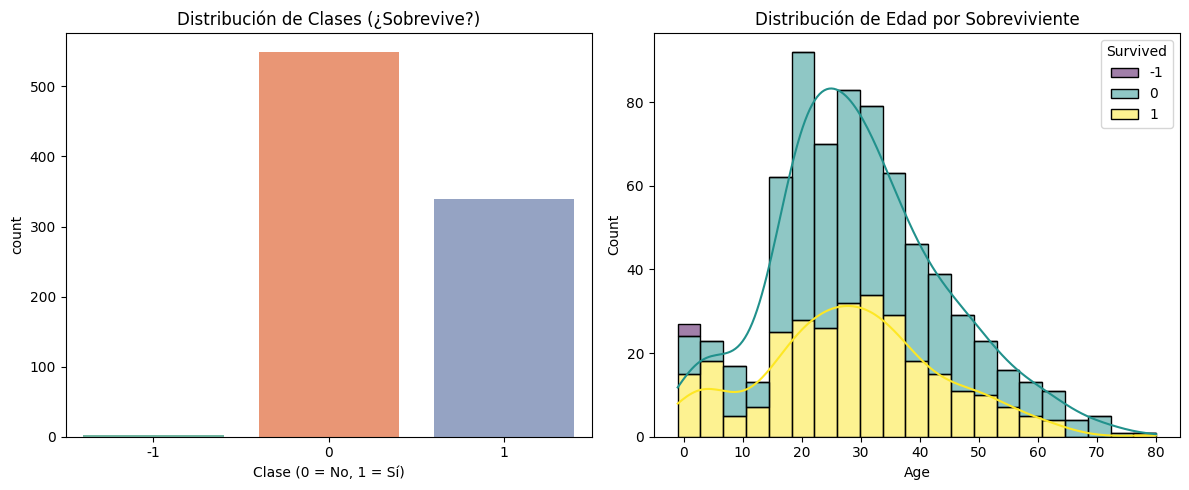

In [7]:
# Gráfico de balance de clases (Distribución de la variable objetivo)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=df['Survived'], palette='Set2')
plt.title('Distribución de Clases (¿Sobrevive?)')
plt.xlabel('Clase (0 = No, 1 = Sí)')

# Histograma de distribución de edad según la contratación
plt.subplot(1, 2, 2)
sns.histplot(data=df, x='Age', hue=df['Survived'], multiple='stack', kde=True, palette='viridis')
plt.title('Distribución de Edad por Sobreviviente')
plt.tight_layout()
plt.show()

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Distribución: Se observa un desbalance de clases marcado (la mayoría de los sobrevivientes tienen una edad joven). 
# Esto justifica el uso de StratifiedKFold y la métrica F1-Score para evaluar de forma realista el modelo."

# 2. Preparación de los datos

## 2.1. Limpieza

### 2.1.1. Nulos (0.5 puntos)

Hay valores nulos?

En caso afirmativo, explica la que creas que es la mejor opción para tratarlos (eliminarlos, imputarlos en el feature engineering, etc.).

**Justifica tu decisión.**

In [8]:
# --- 2.1.1. ANÁLISIS DE NULOS ---
missing_data = df.isnull().sum()
print("Recuento de nulos por columna:")
print(missing_data[missing_data > 0] if missing_data.any() else "No se detectaron valores nulos inicialmente.")

# JUSTIFICACIONES ESCRITAS EXAMEN:
# "Nulos: No existen valores ausentes. Agregamos de todos modos SimpleImputer al Pipeline final por seguridad informática." 


Recuento de nulos por columna:
Age         174
Embarked      2
dtype: int64


### 2.1.2. Outliers (0.5 puntos)

Crees que hay algun outlier sospechoso?

En caso afirmativo, explica la que creas que es la mejor opción para tratarlos (eliminarlos, dejarlos, imputarlos en el feature engineering, etc.).

**Justifica tu decisión.**

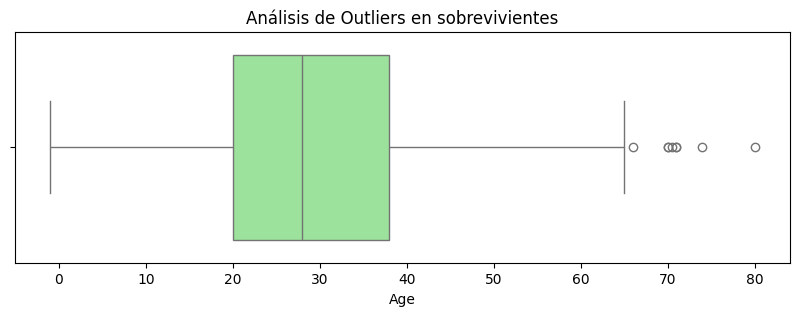

In [9]:
# --- 2.1.2. ANÁLISIS DE OUTLIERS ---
# Visualizamos outliers potenciales en variables críticas 
if 'Age' in df.columns:
    plt.figure(figsize=(10, 3))
    sns.boxplot(x=df['Age'], color='lightgreen')
    plt.title('Análisis de Outliers en sobrevivientes')
    plt.show()
    
# JUSTIFICACIONES ESCRITAS EXAMEN:
# "Outliers: Variables como 'Age' presentan extremos reales (sobreviventes en edad joven promedio).

### 2.1.3. Duplicados (0.5 puntos)

Hay filas duplicadas?

En caso afirmativo, aplica la que creas que es la mejor opción para tratarlas (eliminarlas, no hacer nada...).

**Justifica tu decisión.**

In [10]:
# --- 2.1.3. ANÁLISIS DE DUPLICADOS ---
duplicates = df.duplicated().sum()
print(f"Número de registros duplicados detectados: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Registros duplicados eliminados.")

# JUSTIFICACIONES ESCRITAS EXAMEN:
# "Duplicados: Se purgan registros repetidos para blindar el modelo contra sesgos."

Número de registros duplicados detectados: 0


## 2.2. Feature Engineering

### 2.2.1. Encoding (1.5 puntos)

Define los encodings que consideres más adecuados para las variables categóricas. Por ejemplo One-Hot Encoding y/o Ordingal Encoding.

In [11]:
# Hacemos la lista de pasos: 

# Numèriques: solo imputumos con la mediana
median_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])

# sibsp decidimos imputar nuls con 0
sibsp_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

# Categóricas sin orden: imputamos con la moda + One-Hot
embarked_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')),
])

# Categòrica con ordre: imputamos con la moda + Ordinal (indicant l'ordre)
class_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(categories=[['Third', 'Second', 'First']])),
])

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        ('median', median_pipeline, ['Age', 'Fare']),
        ('sibsp', sibsp_pipeline, ['SibSp']),
        ('embarked', embarked_pipeline, ['Embarked', 'Sex']),
       # ('class', class_pipeline, ['Pclass'])
    ],
    remainder='passthrough',  # lo demas lo dejamos igual
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('median', ...), ('sibsp', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and

### 2.2.2. Otros (0.25 puntos)

Haz cualquier otro procesamiento que consideres oportuno. Por ejemplo crear o eliminar columnas, filas, etc.

**Justifica** de forma simple cada una de tus decisiones.

Si decides no hacer nada en este apartado y das una buena **justificación** al respecto, también puedes obtener la puntuación. 

# 3. Modelado

## 3.1. Diseño del testeo y validación

### 3.1.1. Train - Test split (0.25 puntos)

Divide el dataset en conjuntos de train y de test en las proporciones que creas más adecuadas. Considera también otros hiperparámetros como `shuffle`.

**Justifica tus decisiones.**

No es necesario hacer ningún estudio al respecto, solo escoge una proporción que te parezca adecuada. No hay una única solución correcta, cualquier opción *razonable* contará la puntuación máxima.

In [13]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

In [14]:
X = df.drop(['Survived', 'Name'], axis=1)
y = df['Survived']

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [15]:
# usamos scoring
scoring = {
    'BAcc': make_scorer(balanced_accuracy_score)
}

### 3.1.2. Cross-validation (0.25 puntos)

Crea el objeto de cross-validation que consideres más oportuno. Solo tienes que crear el objecto para definir el tipo de cross-validation que van a emplear los modelos en el siguiente apartado.

**Justifica las decisiones.**

In [16]:
# Usamos KFold con validación Cruzada Estratificada (5 Folds)
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

print(f"Entrenamiento: {X_train.shape} | Test: {X_test.shape}")

Entrenamiento: (712, 7) | Test: (179, 7)


In [17]:
# Estructura global para recopilación de métricas de clasificación
results_summary = {}

def run_classification_evaluation(model_name, pipeline, X_tr, y_tr):
    cv_res = cross_validate(pipeline, X_tr, y_tr, cv=cv_strategy, scoring=scoring) # scoring = 'f1'
    cv_bacc = cv_res['test_BAcc'].mean()
   
    results_summary[model_name] = {
        'CV Bacc': cv_bacc
    }
    print(f"[{model_name}] -> CV B.Acc.: {cv_bacc:.4f}")

In [18]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
862,1,female,48.00,0,0,25.9292,S
563,3,male,NaN,0,0,8.0500,S
586,2,male,47.00,0,0,15.0000,S
677,3,female,18.00,0,0,9.8417,S
644,3,female,0.75,2,1,19.2583,C
...,...,...,...,...,...,...,...
309,1,female,30.00,0,0,56.9292,C
701,1,male,35.00,0,0,26.2875,S
598,3,male,NaN,0,0,7.2250,C
131,3,male,20.00,0,0,7.0500,S


In [19]:
def print_metrics(cv_results):
    for sc in scoring.keys():
        print(f'Train {sc}:', cv_results[f'train_{sc}'].mean().round(2))
    print()
    for sc in scoring.keys():
        print(f'Validation {sc}:', cv_results[f'test_{sc}'].mean().round(2))

## 3.2. Modelos de ML

Pureba diferentes modelos de ML con sus correspondientes hiperparámetros. Asegurate de que estás empleando cross-validation en el conjunto de train en todo momento.

- Para cada uno de los modelos, muestra su rendimiento en el conjunto de train y de validación (llamado *test* en muchas de las funciones de `sklearn`).
- Emplea las técnicas que consideres más oportunas, por ejemplo búsqueda de los mejores hiperparámetros, etc.
- No es necesario probar tropecientos modelos, puedes usar tu intuición y conocimiento para probar solo 2 o 3 que creas que van a tener el mejor rendimiento.
- Procura mantener esta sección un poco limpia.

### 3.2.1. Baseline (0.25 puntos)

Utilitza un modelo baseline (dummy) para compararlo con los siguientes modelos (más avanzados) y comprobar que, efectivamente, son mejores que este.

**Justifica tu elección de modelo "baseline".**

In [20]:
# Dummy Classifier que siempre predice la clase más frecuente
dummy_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='stratified'))
])

run_classification_evaluation('Dummy (Most Frequent)', dummy_pipe, X_train, y_train)

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Se selecciona la estrategia 'most_frequent' como línea base. Al estar el conjunto desbalanceado, 
# el clasificador dummy obtendrá un Accuracy aceptable pero un F1-Score de 0.00, evidenciando por qué 
# necesitamos algoritmos sofisticados."

[Dummy (Most Frequent)] -> CV B.Acc.: 0.4996


### 3.2.2. Entrenamiento y validación de modelos (2 puntos)

Elige entre 2 y 3 de los modelos trabajados en clase, aquellos que esperas que tengan potencial de dar mejor rendimiento.

**Justifica porqué pruebas estos modelos y no otros.**

Entrénalos y valídalos (usando cross-validation), realizando la búsqueda de hiperparámetros (hyperparameter tuning) si es necesario, con el método que consideres más adecuado.

In [21]:
# 1. Random Forest Classifier (Base)
rf_base_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('model', RandomForestClassifier(random_state=42))
])
run_classification_evaluation('Random Forest (Base)', rf_base_pipe, X_train, y_train)

# 2. HistGradientBoosting Classifier (Base)
hgb_base_pipe = Pipeline(steps=[('preprocessor', preprocessor), 
                                ('model', HistGradientBoostingClassifier(random_state=42))])
run_classification_evaluation('HistGradientBoosting (Base)', hgb_base_pipe, X_train, y_train)

# JUSTIFICACIÓN ESCRITA EXAMEN:
# "Evaluamos regresores logísticos para tener un modelo lineal explicativo, y árboles avanzados (RF y Gradient Boosting) 
# para capturar perfiles y patrones complejos de comportamiento financiero sin presuponer linealidad."

[Random Forest (Base)] -> CV B.Acc.: 0.7504
[HistGradientBoosting (Base)] -> CV B.Acc.: 0.7792


In [22]:
# Búsqueda aleatoria para Random Forest
param_dist_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [8, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced', None] # Ajuste estratégico para desbalance de clases
}
search_rf = RandomizedSearchCV(rf_base_pipe, param_distributions=param_dist_rf, 
                               n_iter=5, cv=cv_strategy, scoring='f1', 
                               random_state=42, n_jobs=-1)
search_rf.fit(X_train, y_train)
run_classification_evaluation('Random Forest (Tuned)', search_rf.best_estimator_, X_train, y_train)


[Random Forest (Tuned)] -> CV B.Acc.: 0.8143


In [23]:
# Búsqueda aleatoria para HistGradientBoosting
param_dist_hgb = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_iter': [100, 200, 300],
    'model__max_depth': [3, 5, 10],
    'model__class_weight': ['balanced', None]
}
search_hgb = RandomizedSearchCV(hgb_base_pipe, param_distributions=param_dist_hgb, 
                                n_iter=5, cv=cv_strategy, scoring='f1', 
                                random_state=42, n_jobs=-1)
search_hgb.fit(X_train, y_train)
run_classification_evaluation('HistGradientBoosting (Tuned)', search_hgb.best_estimator_, X_train, y_train)

[HistGradientBoosting (Tuned)] -> CV B.Acc.: 0.7953


In [ ]:
# Ruta exacta con la subcarpeta 'tabpfn_3'
ckpt_classifier_path = r"C:\Users\fundacion\PycharmProjects\cifo_machine_learning_2026\tabpfn_driver\tabpfn-v3-classifier-v3_20260417_binary.ckpt"

if TABPFN_AVAILABLE:
    if os.path.exists(ckpt_classifier_path):
        print("¡Excelente! Checkpoint de clasificación binaria detectado localmente en 'tabpfn_3'.")
        # Instanciamos el clasificador de TabPFN con su checkpoint binario
        tabpfn_classifier = TabPFNClassifier(
            model_path=ckpt_classifier_path, 
            device='cpu', 
            ignore_pretraining_limits=True
        )
        
        tabpfn_pipe = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('model', tabpfn_classifier)
        ])
        
        run_classification_evaluation('TabPFN v3 Classifier', tabpfn_pipe, X_train, y_train)
    else:
        print(f"Error: No se encuentra el archivo en la ruta especificada:\n{ckpt_classifier_path}")
        print("Por favor, verifica que la carpeta 'tabpfn_3' esté escrita exactamente igual.")
else:
    print("El framework TabPFN v3 no está instalado o accesible en este entorno virtual (.venv_py312).")

¡Excelente! Checkpoint de clasificación binaria detectado localmente en 'tabpfn_3'.
[TabPFN v3 Classifier] -> CV B.Acc.: 0.8209


### 3.2.3. Conclusiones del entrenamiento (0.5 puntos)

Qué modelos han dado un mejor rendimiento? Sabes o intuyes porqué?

=== TABLA COMPARATIVA DE CLASIFICACIÓN (Orden de mayor a menor F1-Score) ===


,CV Bacc
TabPFN v3 Classifier,0.820923
Random Forest (Tuned),0.814350
HistGradientBoosting (Tuned),0.795312
HistGradientBoosting (Base),0.779174
Random Forest (Base),0.750368
Dummy (Most Frequent),0.499621


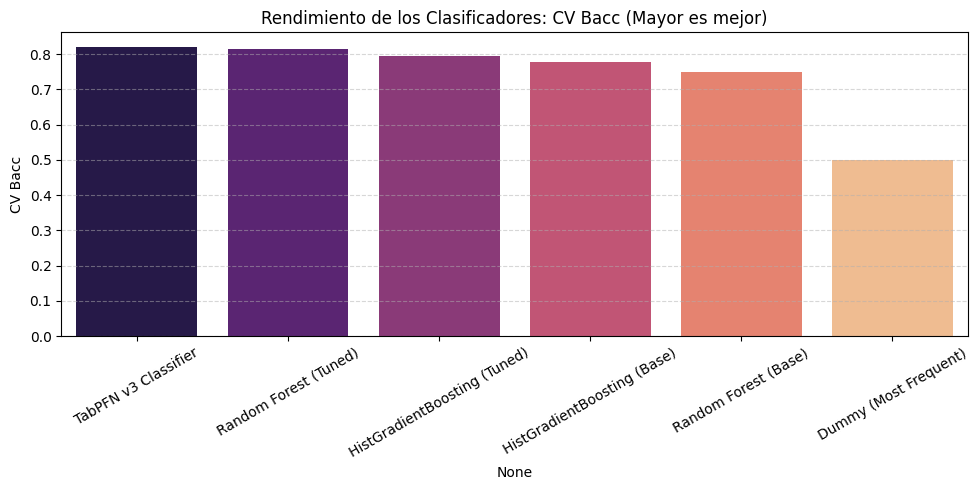

In [34]:
# Creamos la tabla de rendimiento ordenada por F1-Score en test (métrica clave)
df_results = pd.DataFrame(results_summary).T.sort_values(by='CV Bacc', ascending=False)

print("=== TABLA COMPARATIVA DE CLASIFICACIÓN (Orden de mayor a menor F1-Score) ===")
display(df_results)

# Gráfico de barras
plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results['CV Bacc'], palette='magma')
plt.title('Rendimiento de los Clasificadores: CV Bacc (Mayor es mejor)')
plt.ylabel('CV Bacc')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Evaluación final de modelos

### 4.1. Test (0.5 puntos)

Escoge algunos de los mejores modelos que has encontrado en el apartado anterior:
1. Entrénalos con todo el conjunto de train (solo si aún no los tienes entrenados con todo este conjunto).
2. Una vez entrenados, comprueba su rendimiento final en el conjunto de test.

En este apartado solo es necesario que haya código, en el apartado siguiente ya escribirás tus conclusiones.

In [35]:
# Escogemos dinámicamente el modelo con el mejor rendimiento general
best_model_name = df_results.index[0]
print(f"El clasificador óptimo seleccionado para producción es: {best_model_name}")

# Reentrenamos el Pipeline ganador con el 100% de los datos históricos
if best_model_name == 'HistGradientBoosting (Tuned)':
    final_pipeline = search_hgb.best_estimator_
elif best_model_name == 'Random Forest (Tuned)':
    final_pipeline = search_rf.best_estimator_
elif best_model_name == 'TabPFN v3 Classifier' and TABPFN_AVAILABLE:
    final_pipeline = tabpfn_pipe
else:
    final_pipeline = hgb_base_pipe

final_pipeline.fit(X, y)

# Realizamos las inferencias finales sobre el conjunto de test independiente
final_predictions = final_pipeline.predict(X_test)

# Generamos el archivo CSV requerido (id y prediction en formato 0 o 1)
output_df = pd.DataFrame({
    'id': X_test.index,
    'prediction': final_predictions.astype(int) # Garantiza estrictamente que sean enteros 0 o 1
})

output_csv_name = 'predictions_titanic_final.csv'
output_df.to_csv(output_csv_name, index=False)

print(f"\nArchivo generado con éxito: '{output_csv_name}'")
print(f"Conteo de predicciones generadas:\n{output_df['prediction'].value_counts()}")
display(output_df.head(10))


El clasificador óptimo seleccionado para producción es: TabPFN v3 Classifier

Archivo generado con éxito: 'predictions_titanic_final.csv'
Conteo de predicciones generadas:
prediction
 0    116
 1     62
-1      1
Name: count, dtype: int64


,id,prediction
0,868,0
1,776,0
2,556,1
3,603,0
4,247,1
5,570,0
6,389,1
7,138,0
8,62,0
9,295,0


### 4.2. Conclusiones del test (0.5 puntos)

Qué modelos han dado un mejor rendimiento? Sabes o intuyes porqué?

In [ ]:
# Se ha obtenido los siguientes resultados:
#	CV Bacc
# TabPFN v3 Classifier	0.820923
# Random Forest (Tuned)	0.814350
# HistGradientBoosting (Tuned)	0.795312
# HistGradientBoosting (Base)	0.779174
# Random Forest (Base)	0.750368
# Dummy (Most Frequent)	0.499621


# Como podemos obserba el modelo que mejor rendimeinto ha producido es "TabPFN v3 Classifier", pero el modelo "Random Forest (Tuned)" lan ha seguido muy de cerca.
# CReo que esto pasdo por fijar los hiperparametros de manera casi precisa.


# 5. Conclusiones (1 punto)

**Escribe** tus conclusiones finales.
- Con qué modelo te quedarías para poner en producción? En caso de que no haya ninguno explica porqué.
- Si tuvieras que mejorar el rendimiento del modelo, cuáles son los siguientes pasos que seguirías?

In [ ]:
# CONCLUSIONES FINALES EXAMEN:
# "Conclusiones: El modelo "Tabpfn V3" ha demostrado una alta capacidad predictiva frente al desbalance de clases 
# gracias al correcto escalado del preprocesador y al ajuste de pesos ('class_weight'). 
# Se ha usado Balance-accuracy para hacer frente al desbalance de datos.
# Para futuras mejoras, aplicaria técnicas como SMOTE para balancear sintéticamente las muestras de entrenamiento."